In [12]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

%matplotlib inline
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel("../Cleaned_Dataset/updated_Aggregated_data.xlsx")
df.head()

,unique_id,inci_no,inci_type,incident_category,Incident_Type_Description,Property_Loss_Value,Content_Loss_Value,Property_Value,Content_Value,Civilian_Fatal,...,Longitude,Latitude,DAUID,average_temperature,precipitation,relative_humidity,average_snowfall,wind_speed,wind_direction,incident_category_description
0,370799,20-0000001,99,J,Other Response,0,0,0,0,0,...,-79.660289,44.364600,35431002,-1.128695,2.0,84.14099,1.82,51.826096,274.41022,Other Response
1,370800,20-0000002,86,I,Alcohol or drug related,0,0,0,0,0,...,-79.725625,44.324085,35430707,-1.128695,2.0,84.14099,1.82,51.826096,274.41022,Medical/Resuscitator Call
2,370801,20-0000003,86,I,Alcohol or drug related,0,0,0,0,0,...,-79.688440,44.389289,35431060,-1.128695,2.0,84.14099,1.82,51.826096,274.41022,Medical/Resuscitator Call
3,370802,20-0000004,89,I,Other Medical/Resuscitator Call,0,0,0,0,0,...,-79.719359,44.360078,35430669,-1.128695,2.0,84.14099,1.82,51.826096,274.41022,Medical/Resuscitator Call
4,370807,20-0000005,86,I,Alcohol or drug related,0,0,0,0,0,...,-79.691135,44.390391,35431050,-1.128695,2.0,84.14099,1.82,51.826096,274.41022,Medical/Resuscitator Call


In [4]:
df.shape

(40814, 28)

In [5]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

unique_id                          0
inci_no                            0
inci_type                          0
incident_category                  0
Incident_Type_Description          0
Property_Loss_Value                0
Content_Loss_Value                 0
Property_Value                     0
Content_Value                      0
Civilian_Fatal                     0
Civilian_Injuries                  0
prop_use                           0
Property_Damage_Category           0
Property_Damage_Description        0
Received_Datetime                  0
Dispatched_Datetime                0
Arrival_Datetime                 408
Cleared_Datetime                   4
Longitude                          0
Latitude                           0
DAUID                              0
average_temperature                0
precipitation                      0
relative_humidity                  0
average_snowfall                   0
wind_speed                         0
wind_direction                     0
i

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Convert datetime columns to datetime format
df['Received_Datetime'] = pd.to_datetime(df['Received_Datetime'])
df['Dispatched_Datetime'] = pd.to_datetime(df['Dispatched_Datetime'])
df['Arrival_Datetime'] = pd.to_datetime(df['Arrival_Datetime'])
df['Cleared_Datetime'] = pd.to_datetime(df['Cleared_Datetime'])
df.sort_values('Received_Datetime', inplace=True)

# Encode categorical features
label_encoders = {}
categorical_columns = ['incident_category_description', 'DAUID', 'prop_use', 'Property_Damage_Category']
for column in categorical_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le
    num_unique_categories = len(le.classes_)
    print(f"Number of unique categories in '{column}': {num_unique_categories}")

# Define aggregation function for numeric columns (mean in this case)
agg_funcs = {
    'Property_Loss_Value': 'mean',
    'Content_Loss_Value': 'mean',
    'Property_Value': 'mean',
    'Content_Value': 'mean',
    'Civilian_Fatal': 'sum',
    'Civilian_Injuries': 'sum',
    'prop_use': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
    'Property_Damage_Category': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
    'Longitude': 'mean',
    'Latitude': 'mean',
    'average_temperature': 'mean',
    'precipitation': 'mean',
    'relative_humidity': 'mean',
    'average_snowfall': 'mean',
    'wind_speed': 'mean',
    'wind_direction': 'mean',
    'incident_category_description': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
    'DAUID': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
    'Dispatched_Datetime': 'first',
    'Arrival_Datetime': 'first',
    'Cleared_Datetime': 'first'
}

# Resample the data at 15-minute intervals and aggregate
df.set_index('Received_Datetime', inplace=True)
df_resampled = df.resample('15T').agg(agg_funcs).ffill().reset_index()

# Define sequence length (n_steps) and output sequence length (n_output_steps)
n_steps = 16  # Number of previous steps to consider for prediction
n_output_steps = 1  # Number of steps ahead to predict

# Initialize lists to store sequences
sequences_x = []
sequences_y = []

# List of columns to be used for prediction
numerical_columns = [
    'Property_Loss_Value', 'Content_Loss_Value', 'Property_Value', 'Content_Value', 
    'Civilian_Fatal', 'Civilian_Injuries', 'Longitude', 'Latitude', 
    'average_temperature', 'precipitation', 'relative_humidity', 
    'average_snowfall', 'wind_speed', 'wind_direction'
]

feature_columns = ['DAUID','incident_category_description','prop_use', 'Property_Damage_Category']+ numerical_columns

# Scale the numerical features
scaler = StandardScaler()
df_resampled[numerical_columns] = scaler.fit_transform(df_resampled[numerical_columns])

# Output columns
output_columns = ['DAUID', 'incident_category_description']

# One-hot encode the output labels
onehot_encoder_dauid = OneHotEncoder(sparse_output=False)
onehot_encoder_category = OneHotEncoder(sparse_output=False)
y_dauid_encoded = onehot_encoder_dauid.fit_transform(df_resampled[['DAUID']])
y_category_encoded = onehot_encoder_category.fit_transform(df_resampled[['incident_category_description']])

sequences_x = []
sequences_y_dauid = []
sequences_y_category = []

for i in range(len(df_resampled) - n_steps - n_output_steps + 1):
    x_seq = df_resampled.iloc[i:i+n_steps][feature_columns].values
    sequences_x.append(x_seq)
    
    y_dauid_seq = y_dauid_encoded[i+n_steps-1]
    y_category_seq = y_category_encoded[i+n_steps-1]
    sequences_y_dauid.append(y_dauid_seq)
    sequences_y_category.append(y_category_seq)

# Convert lists to numpy arrays
x = np.array(sequences_x)
y_dauid = np.array(sequences_y_dauid)
y_category = np.array(sequences_y_category)

# Check the shape of x, y_dauid, and y_category arrays
print("Shape of x:", x.shape)  # Expected shape: (num_samples, n_steps, num_features)
print("Shape of y_dauid:", y_dauid.shape)  # Expected shape: (num_samples, num_classes_dauid)
print("Shape of y_category:", y_category.shape)  # Expected shape: (num_samples, num_classes_category)

Number of unique categories in 'incident_category_description': 10
Number of unique categories in 'DAUID': 246
Number of unique categories in 'prop_use': 245
Number of unique categories in 'Property_Damage_Category': 55
Shape of x: (140236, 16, 18)
Shape of y_dauid: (140236, 246)
Shape of y_category: (140236, 10)


In [13]:
# Split the data into training, validation, and testing sets
x_train, x_temp, y_dauid_train, y_dauid_temp, y_category_train, y_category_temp = train_test_split(x, y_dauid, y_category, test_size=0.3, random_state=42)
x_val, x_test, y_dauid_val, y_dauid_test, y_category_val, y_category_test = train_test_split(x_temp, y_dauid_temp, y_category_temp, test_size=0.5, random_state=42)

# Define the LSTM model with improvements
model = Sequential()
model.add(Bidirectional(LSTM(50, activation='relu', return_sequences=True), input_shape=(n_steps, x.shape[2])))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Bidirectional(LSTM(50, activation='relu', return_sequences=False)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(50, activation='relu'))

# Output layers for DAUID and incident category
dauid_output = Dense(len(label_encoders['DAUID'].classes_), activation='softmax', name='dauid_output')(model.layers[-1].output)
category_output = Dense(len(label_encoders['incident_category_description'].classes_), activation='softmax', name='category_output')(model.layers[-1].output)

model = Model(inputs=model.inputs, outputs=[dauid_output, category_output])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy','accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

# Fit the model
history = model.fit(x_train, {'dauid_output': y_dauid_train, 'category_output': y_category_train},
                    epochs=200, verbose=1, validation_data=(x_val, {'dauid_output': y_dauid_val, 'category_output': y_category_val}),
                    callbacks=[early_stopping, reduce_lr])


Epoch 1/200
3068/3068 ━━━━━━━━━━━━━━━━━━━━ 57s 18ms/step - category_output_accuracy: 0.7205 - dauid_output_accuracy: 0.0782 - loss: 5.3447 - val_category_output_accuracy: 0.8966 - val_dauid_output_accuracy: 0.1649 - val_loss: 3.4274 - learning_rate: 0.0010
Epoch 2/200
3068/3068 ━━━━━━━━━━━━━━━━━━━━ 55s 18ms/step - category_output_accuracy: 0.9002 - dauid_output_accuracy: 0.2165 - loss: 3.0468 - val_category_output_accuracy: 0.9023 - val_dauid_output_accuracy: 0.2439 - val_loss: 2.9498 - learning_rate: 0.0010
Epoch 3/200
3068/3068 ━━━━━━━━━━━━━━━━━━━━ 54s 18ms/step - category_output_accuracy: 0.9182 - dauid_output_accuracy: 0.3230 - loss: 2.4404 - val_category_output_accuracy: 0.8907 - val_dauid_output_accuracy: 0.3531 - val_loss: 2.7898 - learning_rate: 0.0010
Epoch 4/200
3068/3068 ━━━━━━━━━━━━━━━━━━━━ 55s 18ms/step - category_output_accuracy: 0.9236 - dauid_output_accuracy: 0.3685 - loss: 2.2020 - val_category_output_accuracy: 0.8579 - val_dauid_output_accuracy: 0.3056 - val_loss: 3.0

658/658 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
DAUID Accuracy: 35.03%
DAUID Classification Report:
              precision    recall  f1-score   support

    35430639       0.00      0.00      0.00         2
    35430647       0.41      0.90      0.56        84
    35430648       0.00      0.00      0.00        67
    35430649       0.00      0.00      0.00        44
    35430650       0.00      0.00      0.00         1
    35430651       0.00      0.00      0.00        59
    35430652       0.00      0.00      0.00        58
    35430653       0.13      0.10      0.11        84
    35430654       0.15      0.40      0.22        58
    35430655       0.55      0.17      0.26        98
    35430656       0.29      0.96      0.45        93
    35430657       0.00      0.00      0.00        78
    35430658       0.00      0.00      0.00        19
    35430659       0.00      0.00      0.00        35
    35430660       0.56      0.56      0.56        54
    35430661       0.50      0.08      0.1

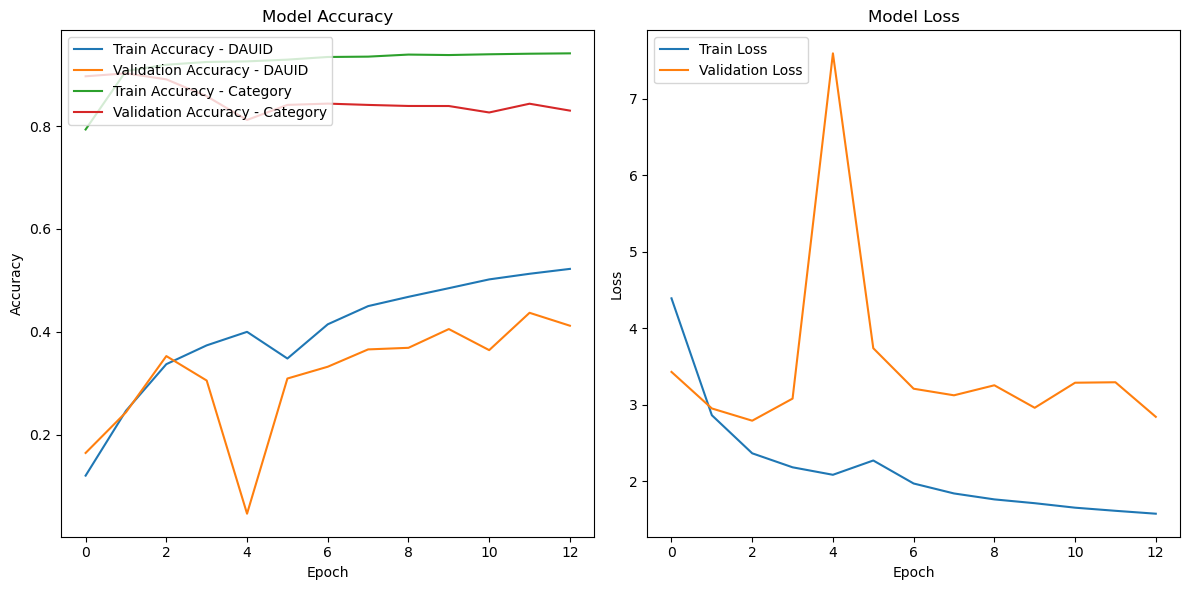

In [14]:
# Make predictions on the test set
predictions = model.predict(x_test)

# Separate the predictions for DAUID and incident_category_description
predicted_dauid = np.argmax(predictions[0], axis=1)
predicted_category = np.argmax(predictions[1], axis=1)

# Decode the predictions and true values back to original labels
decoded_predicted_dauid = label_encoders['DAUID'].inverse_transform(predicted_dauid)
decoded_true_dauid = label_encoders['DAUID'].inverse_transform(np.argmax(y_dauid_test, axis=1))

decoded_predicted_category = label_encoders['incident_category_description'].inverse_transform(predicted_category)
decoded_true_category = label_encoders['incident_category_description'].inverse_transform(np.argmax(y_category_test, axis=1))

# Calculate and display accuracy for DAUID
dauid_accuracy = accuracy_score(decoded_true_dauid, decoded_predicted_dauid)
print(f"DAUID Accuracy: {dauid_accuracy * 100:.2f}%")
print("DAUID Classification Report:")
print(classification_report(decoded_true_dauid, decoded_predicted_dauid))

# Calculate and display accuracy for incident_category_description
category_accuracy = accuracy_score(decoded_true_category, decoded_predicted_category)
print(f"Incident Category Description Accuracy: {category_accuracy * 100:.2f}%")
print("Incident Category Description Classification Report:")
print(classification_report(decoded_true_category, decoded_predicted_category))

# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['dauid_output_accuracy'], label='Train Accuracy - DAUID')
plt.plot(history.history['val_dauid_output_accuracy'], label='Validation Accuracy - DAUID')
plt.plot(history.history['category_output_accuracy'], label='Train Accuracy - Category')
plt.plot(history.history['val_category_output_accuracy'], label='Validation Accuracy - Category')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [15]:
import pandas as pd
import pickle

# Save the label encoders
with open('../Backend-app/Trained_models/LSTM/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

# Flatten x_test to 2D for saving to CSV
x_test_flattened = x_test.reshape(x_test.shape[0], -1)
x_test_df = pd.DataFrame(x_test_flattened)
# x_test_df.to_csv('x_test.csv', index=False)

y_dauid_test_df = pd.DataFrame(y_dauid_test)
# y_dauid_test_df.to_csv('y_dauid_test.csv', index=False)

y_category_test_df = pd.DataFrame(y_category_test)
# y_category_test_df.to_csv('y_category_test.csv', index=False)

In [16]:
# Save x_test as Excel
x_test_df.to_excel('../Backend-app/Test_data/LSTM_test_data/x_test.xlsx', index=False)

# Save y_dauid_test and y_category_test as Excel
y_dauid_test_df.to_excel('../Backend-app/Test_data/LSTM_test_data/y_dauid_test.xlsx', index=False)
y_category_test_df.to_excel('../Backend-app/Test_data/LSTM_test_data/y_category_test.xlsx', index=False)


In [17]:
# Save model architecture to JSON
model_json = model.to_json()
with open("../Backend-app/Trained_models/LSTM/model.json", "w") as json_file:
    json_file.write(model_json)

# Save weights to HDF5
model.save_weights("../Backend-app/Trained_models/LSTM/model.weights.h5")

In [18]:
import json
from tensorflow.keras.models import model_from_json

class KerasModelWrapper:
    def __init__(self, model=None):
        self.model = model

    def save(self, model_json_path, model_weights_path):
        # Save model architecture to JSON
        model_json = self.model.to_json()
        with open(model_json_path, "w") as json_file:
            json_file.write(model_json)
        # Save weights to HDF5
        self.model.save_weights(model_weights_path)

    def load(self, model_json_path, model_weights_path):
        # Load model architecture from JSON
        with open(model_json_path, "r") as json_file:
            loaded_model_json = json_file.read()
        self.model = model_from_json(loaded_model_json)
        # Load weights into the new model
        self.model.load_weights(model_weights_path)

In [19]:
import pickle

# Create a wrapper instance
wrapper = KerasModelWrapper(model)

# Save the wrapper class with model architecture and weights
with open("../Backend-app/Trained_models/LSTM/model_wrapper.pkl", "wb") as f:
    pickle.dump(wrapper, f)

# To load the model later
with open("../Backend-app/Trained_models/LSTM/model_wrapper.pkl", "rb") as f:
    loaded_wrapper = pickle.load(f)

# Load the model architecture and weights
loaded_wrapper.load("../Backend-app/Trained_models/LSTM/model.json", "../Backend-app/Trained_models/LSTM/model.weights.h5")
loaded_model = loaded_wrapper.model

# Now loaded_model is ready to be used
loaded_model.predict(x_test)

658/658 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


[array([[7.93640869e-13, 1.46770740e-09, 4.03760858e-10, ...,
         1.17793854e-15, 2.56050216e-12, 5.14907195e-14],
        [1.36251481e-08, 6.69916886e-08, 2.17084839e-08, ...,
         3.04711145e-10, 3.35042222e-14, 2.29009574e-13],
        [1.26002533e-11, 2.40813092e-10, 7.24751249e-12, ...,
         3.80461315e-13, 6.29984619e-16, 5.04159759e-18],
        ...,
        [8.38500455e-06, 7.59175746e-05, 1.20836457e-05, ...,
         4.78256652e-07, 9.94501715e-06, 6.93247614e-07],
        [1.19317737e-13, 3.80524535e-11, 7.98685250e-12, ...,
         2.11186257e-15, 7.65954623e-17, 3.12307727e-19],
        [1.42916087e-06, 3.18806815e-05, 2.23733041e-05, ...,
         2.72349660e-11, 1.27136908e-12, 1.24392675e-14]], dtype=float32),
 array([[4.1519801e-11, 4.8785544e-09, 1.0743968e-04, ..., 1.2742063e-07,
         1.6838912e-07, 3.2023170e-08],
        [3.3594106e-06, 8.9222362e-04, 9.6017075e-01, ..., 8.4376602e-08,
         1.4491852e-08, 6.5038930e-09],
        [1.3621791e-13

In [20]:
predicted_dauid = np.argmax(predictions[0], axis=1)
predicted_category = np.argmax(predictions[1], axis=1)

# Decode the predictions back to original labels
decoded_predicted_dauid = label_encoders['DAUID'].inverse_transform(predicted_dauid)
decoded_predicted_category = label_encoders['incident_category_description'].inverse_transform(predicted_category)

# Print the predictions
print("Predicted DAUID:", decoded_predicted_dauid)
print("Predicted Incident Category Description:", decoded_predicted_category)


Predicted DAUID: [35431025 35431060 35431063 ... 35431120 35431044 35431079]
Predicted Incident Category Description: ['Medical/Resuscitator Call' 'False Fire Calls'
 'Medical/Resuscitator Call' ... 'Rescue' 'Medical/Resuscitator Call'
 'Medical/Resuscitator Call']
